# 代理模型详解与应用

代理模型（Surrogate Model）是优化框架中的重要组件，用于：

1. **降低计算成本** - 用近似模型替代昂贵的真实评估
2. **加速优化过程** - 快速筛选候选解
3. **处理噪声数据** - 提供平滑的函数近似
4. **全局视角** - 理解整个搜索空间的结构

NSGABLACK框架支持多种代理模型，可与偏置系统和优化算法无缝集成。

In [2]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("环境准备完成")
print(f"NumPy版本: {np.__version__}")

环境准备完成
NumPy版本: 2.1.3


## 代理模型基类与接口

In [3]:
class SurrogateBase:
    """代理模型基类"""
    
    def __init__(self, name="SurrogateBase"):
        self.name = name
        self.X_train = None
        self.y_train = None
        self.is_fitted = False
        
        print(f"创建代理模型: {self.name}")
    
    def fit(self, X, y):
        """训练代理模型"""
        raise NotImplementedError
    
    def predict(self, X):
        """预测函数值"""
        raise NotImplementedError
    
    def predict_with_uncertainty(self, X):
        """预测函数值和不确定性（可选）"""
        mean = self.predict(X)
        return mean, np.zeros(len(X))
    
    def update(self, X_new, y_new):
        """增量更新模型"""
        if self.X_train is None:
            self.X_train = X_new.reshape(1, -1) if X_new.ndim == 1 else X_new
            self.y_train = np.array([y_new]) if np.isscalar(y_new) else y_new
        else:
            if X_new.ndim == 1:
                X_new = X_new.reshape(1, -1)
            self.X_train = np.vstack([self.X_train, X_new])
            self.y_train = np.append(self.y_train, y_new)
        
        self.fit(self.X_train, self.y_train)
    
    def evaluate_quality(self, X_test, y_test):
        """评估模型质量"""
        if not self.is_fitted:
            print("模型尚未训练")
            return None
        
        y_pred = self.predict(X_test)
        
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        mae = np.mean(np.abs(y_test - y_pred))
        
        return {
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2,
            'MAE': mae
        }

print("\n代理模型基类已定义")


代理模型基类已定义


## 1. 高斯过程代理模型


测试高斯过程代理模型：
创建代理模型: GaussianProcess
高斯过程训练完成 - 样本数: 20
优化后的核函数: 1.02**2 * RBF(length_scale=0.000337)


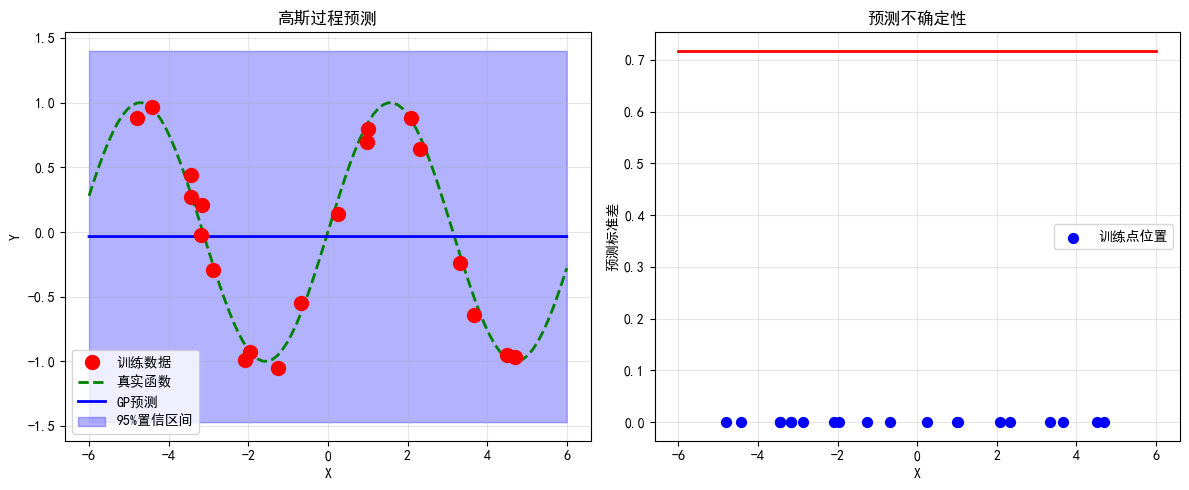


模型质量评估：
  MSE: 0.5190
  RMSE: 0.7204
  R2: -0.0024
  MAE: 0.6563


In [4]:
class GaussianProcessSurrogate(SurrogateBase):
    """高斯过程代理模型"""
    
    def __init__(self, kernel_type='rbf', length_scale=1.0, alpha=1e-10):
        super().__init__("GaussianProcess")
        self.kernel_type = kernel_type
        self.length_scale = length_scale
        self.alpha = alpha
        self.scaler_X = StandardScaler()
        self.scaler_y = StandardScaler()
        self.gpr = None
        
        # 设置核函数
        if kernel_type == 'rbf':
            kernel = ConstantKernel(1.0) * RBF(length_scale=length_scale)
        elif kernel_type == 'matern':
            kernel = ConstantKernel(1.0) * Matern(length_scale=length_scale, nu=2.5)
        else:
            kernel = RBF(length_scale=length_scale)
        
        self.gpr = GaussianProcessRegressor(
            kernel=kernel,
            alpha=alpha,
            n_restarts_optimizer=10,
            normalize_y=True
        )
    
    def fit(self, X, y):
        """训练高斯过程"""
        # 数据标准化
        self.X_train = X
        self.y_train = y
        
        X_scaled = self.scaler_X.fit_transform(X)
        y_scaled = self.scaler_y.fit_transform(y.reshape(-1, 1)).ravel()
        
        # 训练模型
        self.gpr.fit(X_scaled, y_scaled)
        self.is_fitted = True
        
        print(f"高斯过程训练完成 - 样本数: {len(X)}")
        print(f"优化后的核函数: {self.gpr.kernel_}")
    
    def predict(self, X):
        """预测"""
        if not self.is_fitted:
            raise ValueError("模型尚未训练")
        
        X_scaled = self.scaler_X.transform(X)
        y_scaled_pred = self.gpr.predict(X_scaled)
        y_pred = self.scaler_y.inverse_transform(y_scaled_pred.reshape(-1, 1)).ravel()
        
        return y_pred
    
    def predict_with_uncertainty(self, X):
        """预测和不确定性"""
        if not self.is_fitted:
            raise ValueError("模型尚未训练")
        
        X_scaled = self.scaler_X.transform(X)
        y_scaled_pred, y_scaled_std = self.gpr.predict(X_scaled, return_std=True)
        
        y_pred = self.scaler_y.inverse_transform(y_scaled_pred.reshape(-1, 1)).ravel()
        y_std = y_scaled_std * self.scaler_y.scale_[0]  # 反标准化标准差
        
        return y_pred, y_std

# 测试高斯过程
print("\n测试高斯过程代理模型：")
print("=" * 50)

# 生成测试数据
np.random.seed(42)
X_train = np.random.uniform(-5, 5, 20).reshape(-1, 1)
y_train = np.sin(X_train).flatten() + 0.1 * np.random.normal(0, 1, 20)

# 创建和训练模型
gp_surrogate = GaussianProcessSurrogate(kernel_type='rbf', length_scale=1.0)
gp_surrogate.fit(X_train, y_train)

# 生成测试点
X_test = np.linspace(-6, 6, 100).reshape(-1, 1)
y_true = np.sin(X_test).flatten()

# 预测
y_pred, y_std = gp_surrogate.predict_with_uncertainty(X_test)

# 可视化
plt.figure(figsize=(12, 5))

# 预测结果
plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, c='red', s=100, zorder=5, label='训练数据')
plt.plot(X_test, y_true, 'g--', linewidth=2, label='真实函数')
plt.plot(X_test, y_pred, 'b-', linewidth=2, label='GP预测')
plt.fill_between(X_test.flatten(), y_pred - 2*y_std, y_pred + 2*y_std, 
                 alpha=0.3, color='blue', label='95%置信区间')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('高斯过程预测')
plt.legend()
plt.grid(True, alpha=0.3)

# 不确定性
plt.subplot(1, 2, 2)
plt.plot(X_test, y_std, 'r-', linewidth=2)
plt.scatter(X_train, np.zeros(len(X_train)), c='blue', s=50, 
           zorder=5, label='训练点位置')
plt.xlabel('X')
plt.ylabel('预测标准差')
plt.title('预测不确定性')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 评估模型质量
y_test = np.sin(X_test).flatten()
quality = gp_surrogate.evaluate_quality(X_test, y_test)

print("\n模型质量评估：")
for metric, value in quality.items():
    print(f"  {metric}: {value:.4f}")

## 2. 径向基函数（RBF）代理模型

In [ ]:
class RBFSurrogate(SurrogateBase):
    """径向基函数代理模型"""
    
    def __init__(self, epsilon=1.0, smoothing=0.0):
        super().__init__("RBF")
        self.epsilon = epsilon
        self.smoothing = smoothing
        self.centers = None
        self.weights = None
    
    def _rbf_kernel(self, X1, X2):
        """RBF核函数"""
        distances = cdist(X1, X2, 'euclidean')
        return np.exp(-(self.epsilon * distances) ** 2)
    
    def fit(self, X, y):
        """训练RBF模型"""
        self.X_train = X
        self.y_train = y
        self.centers = X  # 使用训练点作为中心
        
        # 构建插值矩阵
        G = self._rbf_kernel(self.centers, self.centers)
        
        # 添加平滑项
        if self.smoothing > 0:
            G += self.smoothing * np.eye(len(G))
        
        # 求解权重
        self.weights = np.linalg.solve(G, y)
        self.is_fitted = True
        
        print(f"RBF模型训练完成 - 中心点数: {len(self.centers)}")
    
    def predict(self, X):
        """预测"""
        if not self.is_fitted:
            raise ValueError("模型尚未训练")
        
        G = self._rbf_kernel(X, self.centers)
        return G @ self.weights

# 测试RBF代理模型
print("\n测试RBF代理模型：")
print("=" * 50)

# 使用相同的测试数据
rbf_surrogate = RBFSurrogate(epsilon=0.5, smoothing=1e-8)
rbf_surrogate.fit(X_train, y_train)

# 预测
y_pred_rbf = rbf_surrogate.predict(X_test)

# 可视化对比
plt.figure(figsize=(12, 5))

# RBF预测
plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, c='red', s=100, zorder=5, label='训练数据')
plt.plot(X_test, y_true, 'g--', linewidth=2, label='真实函数')
plt.plot(X_test, y_pred_rbf, 'b-', linewidth=2, label='RBF预测')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('RBF代理模型预测')
plt.legend()
plt.grid(True, alpha=0.3)

# 误差分析
plt.subplot(1, 2, 2)
error = y_pred_rbf - y_true
plt.plot(X_test, error, 'r-', linewidth=2)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('X')
plt.ylabel('预测误差')
plt.title('RBF预测误差')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 评估质量
quality_rbf = rbf_surrogate.evaluate_quality(X_test, y_test)
print("\nRBF模型质量评估：")
for metric, value in quality_rbf.items():
    print(f"  {metric}: {value:.4f}")

## 3. 多项式回归代理模型

In [ ]:
class PolynomialSurrogate(SurrogateBase):
    """多项式回归代理模型"""
    
    def __init__(self, degree=2):
        super().__init__("Polynomial")
        self.degree = degree
        self.coefficients = None
        
    def _polynomial_features(self, X):
        """生成多项式特征"""
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        n_samples, n_features = X.shape
        features = [np.ones(n_samples)]  # 常数项
        
        # 添加所有单项式
        for d in range(1, self.degree + 1):
            for i in range(n_features):
                features.append(X[:, i] ** d)
            
            # 添加交叉项（仅对二维情况）
            if n_features == 2 and d == 2:
                features.append(X[:, 0] * X[:, 1])
        
        return np.column_stack(features)
    
    def fit(self, X, y):
        """训练多项式回归"""
        self.X_train = X
        self.y_train = y
        
        # 构建特征矩阵
        Phi = self._polynomial_features(X)
        
        # 最小二乘求解
        self.coefficients = np.linalg.lstsq(Phi, y, rcond=None)[0]
        self.is_fitted = True
        
        print(f"多项式模型训练完成 - 阶数: {self.degree}, 特征数: {len(self.coefficients)}")
    
    def predict(self, X):
        """预测"""
        if not self.is_fitted:
            raise ValueError("模型尚未训练")
        
        Phi = self._polynomial_features(X)
        return Phi @ self.coefficients

# 测试多项式代理模型
print("\n测试多项式代理模型：")
print("=" * 50)

# 测试不同阶数的多项式
degrees = [1, 3, 5, 7]
plt.figure(figsize=(15, 10))

for i, degree in enumerate(degrees):
    poly_surrogate = PolynomialSurrogate(degree=degree)
    poly_surrogate.fit(X_train, y_train)
    y_pred_poly = poly_surrogate.predict(X_test)
    
    plt.subplot(2, 2, i+1)
    plt.scatter(X_train, y_train, c='red', s=100, zorder=5, label='训练数据')
    plt.plot(X_test, y_true, 'g--', linewidth=2, label='真实函数')
    plt.plot(X_test, y_pred_poly, 'b-', linewidth=2, label=f'多项式(阶数={degree})')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'多项式回归 - 阶数={degree}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 评估并添加文本
    quality = poly_surrogate.evaluate_quality(X_test, y_test)
    plt.text(0.02, 0.98, f"RMSE: {quality['RMSE']:.4f}\nR²: {quality['R2']:.4f}",
             transform=plt.gca().transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# 分析过拟合现象
print("\n分析多项式阶数对性能的影响：")
print("-" * 50)

train_errors = []
test_errors = []
degrees_range = range(1, 11)

for degree in degrees_range:
    poly_surrogate = PolynomialSurrogate(degree=degree)
    poly_surrogate.fit(X_train, y_train)
    
    # 训练误差
    y_train_pred = poly_surrogate.predict(X_train)
    train_error = np.mean((y_train_pred - y_train) ** 2)
    train_errors.append(train_error)
    
    # 测试误差
    y_test_pred = poly_surrogate.predict(X_test)
    test_error = np.mean((y_test_pred - y_test) ** 2)
    test_errors.append(test_error)

# 绘制学习曲线
plt.figure(figsize=(10, 5))
plt.plot(degrees_range, train_errors, 'b-o', linewidth=2, label='训练误差')
plt.plot(degrees_range, test_errors, 'r-o', linewidth=2, label='测试误差')
plt.xlabel('多项式阶数')
plt.ylabel('均方误差')
plt.title('过拟合分析')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

print("\n观察：")
print("- 低阶多项式：欠拟合，训练和测试误差都较高")
print("- 中等阶数：较好平衡，泛化能力强")
print("- 高阶多项式：过拟合，训练误差低但测试误差高")

## 4. 基于树的代理模型

In [ ]:
class TreeBasedSurrogate(SurrogateBase):
    """基于树的代理模型（随机森林）"""
    
    def __init__(self, n_estimators=100, max_depth=None, min_samples_split=2):
        super().__init__("RandomForest")
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.model = None
    
    def fit(self, X, y):
        """训练随机森林"""
        self.X_train = X
        self.y_train = y
        
        self.model = RandomForestRegressor(
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            random_state=42
        )
        
        self.model.fit(X, y)
        self.is_fitted = True
        
        print(f"随机森林训练完成 - 树的数量: {self.n_estimators}")
    
    def predict(self, X):
        """预测"""
        if not self.is_fitted:
            raise ValueError("模型尚未训练")
        
        return self.model.predict(X)
    
    def predict_with_uncertainty(self, X):
        """预测和不确定性（通过树的标准差）"""
        if not self.is_fitted:
            raise ValueError("模型尚未训练")
        
        # 获取每棵树的预测
        predictions = np.array([tree.predict(X) for tree in self.model.estimators_])
        
        # 计算均值和标准差
        mean_pred = np.mean(predictions, axis=0)
        std_pred = np.std(predictions, axis=0)
        
        return mean_pred, std_pred
    
    def get_feature_importance(self):
        """获取特征重要性"""
        if not self.is_fitted:
            return None
        return self.model.feature_importances_

# 测试基于树的代理模型
print("\n测试基于树的代理模型：")
print("=" * 50)

# 创建二维测试数据
np.random.seed(42)
n_samples = 100
X_2d = np.random.uniform(-3, 3, (n_samples, 2))
y_2d = (np.sin(X_2d[:, 0]) * np.cos(X_2d[:, 1]) + 
        0.1 * np.random.normal(0, 1, n_samples))

# 训练模型
tree_surrogate = TreeBasedSurrogate(n_estimators=100, max_depth=5)
tree_surrogate.fit(X_2d, y_2d)

# 特征重要性
importance = tree_surrogate.get_feature_importance()
print(f"\n特征重要性：")
print(f"  特征1 (X): {importance[0]:.4f}")
print(f"  特征2 (Y): {importance[1]:.4f}")

# 可视化预测结果
plt.figure(figsize=(15, 5))

# 创建网格用于可视化
x_grid = np.linspace(-3, 3, 50)
y_grid = np.linspace(-3, 3, 50)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
grid_points = np.column_stack([X_grid.ravel(), Y_grid.ravel()])

# 预测
Z_pred = tree_surrogate.predict(grid_points).reshape(X_grid.shape)
Z_pred_std = tree_surrogate.predict_with_uncertainty(grid_points)[1].reshape(X_grid.shape)

# 预测均值
plt.subplot(1, 3, 1)
plt.contourf(X_grid, Y_grid, Z_pred, levels=20, cmap='viridis')
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, s=30, 
           cmap='coolwarm', edgecolor='white')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('随机森林预测')
plt.colorbar(label='预测值')

# 预测不确定性
plt.subplot(1, 3, 2)
plt.contourf(X_grid, Y_grid, Z_pred_std, levels=20, cmap='plasma')
plt.scatter(X_2d[:, 0], X_2d[:, 1], c='red', s=10, alpha=0.5)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('预测不确定性')
plt.colorbar(label='标准差')

# 残差图
plt.subplot(1, 3, 3)
y_pred_2d = tree_surrogate.predict(X_2d)
residuals = y_2d - y_pred_2d
plt.scatter(y_pred_2d, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('预测值')
plt.ylabel('残差')
plt.title('残差分析')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 代理模型比较与选择指南

In [ ]:
# 代理模型综合比较
print("\n代理模型综合比较：")
print("=" * 60)

# 创建测试函数
def test_function_2d(X):
    """二维测试函数"""
    x, y = X[:, 0], X[:, 1]
    return (x**2 + y**2) * np.exp(-(x**2 + y**2) / 10)

# 生成训练数据
np.random.seed(42)
n_train = 50
X_train_2d = np.random.uniform(-5, 5, (n_train, 2))
y_train_2d = test_function_2d(X_train_2d)

# 生成测试数据
n_test = 200
X_test_2d = np.random.uniform(-5, 5, (n_test, 2))
y_test_2d = test_function_2d(X_test_2d)

# 测试不同代理模型
models = {
    '高斯过程': GaussianProcessSurrogate(kernel_type='rbf'),
    'RBF': RBFSurrogate(epsilon=0.5),
    '随机森林': TreeBasedSurrogate(n_estimators=100)
}

results = {}
predictions = {}

for name, model in models.items():
    print(f"\n训练 {name} 模型...")
    model.fit(X_train_2d, y_train_2d)
    
    # 预测
    y_pred = model.predict(X_test_2d)
    predictions[name] = y_pred
    
    # 评估
    quality = model.evaluate_quality(X_test_2d, y_test_2d)
    results[name] = quality
    
    print(f"  RMSE: {quality['RMSE']:.4f}")
    print(f"  R²: {quality['R2']:.4f}")

# 可视化比较
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 创建网格用于可视化
x_grid = np.linspace(-5, 5, 50)
y_grid = np.linspace(-5, 5, 50)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
grid_points = np.column_stack([X_grid.ravel(), Y_grid.ravel()])
Z_true = test_function_2d(grid_points).reshape(X_grid.shape)

# 真实函数
ax1 = axes[0, 0]
contour = ax1.contourf(X_grid, Y_grid, Z_true, levels=20, cmap='viridis')
ax1.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c='red', s=30, 
           edgecolor='white', label='训练点')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_title('真实函数')
ax1.legend()
plt.colorbar(contour, ax=ax1)

# 各模型预测
for i, (name, model) in enumerate(models.items()):
    ax = axes[(i+1)//2, (i+1)%2]
    
    Z_pred = model.predict(grid_points).reshape(X_grid.shape)
    contour = ax.contourf(X_grid, Y_grid, Z_pred, levels=20, cmap='viridis')
    
    # 添加评估指标
    quality = results[name]
    ax.text(0.02, 0.98, f"{name}\nRMSE: {quality['RMSE']:.3f}\nR²: {quality['R2']:.3f}",
           transform=ax.transAxes, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'{name}预测')
    plt.colorbar(contour, ax=ax)

plt.tight_layout()
plt.show()

# 性能对比表格
print("\n" + "="*60)
print("代理模型性能对比：")
print("="*60)
print(f"{'模型':<15} {'RMSE':<10} {'R²':<10} {'MAE':<10} {'计算成本':<10}")
print("-"*60)

model_costs = {
    '高斯过程': '高',
    'RBF': '中',
    '随机森林': '中低'
}

for name, quality in results.items():
    cost = model_costs.get(name, '未知')
    print(f"{name:<15} {quality['RMSE']:<10.4f} {quality['R2']:<10.4f} "
          f"{quality['MAE']:<10.4f} {cost:<10}")

print("\n选择指南：")
print("-" * 40)
print("高斯过程：")
print("  ✓ 提供不确定性量化")
print("  ✓ 适合小样本问题")
print("  ✗ 计算成本高(O(n³))")
print("  ✗ 不适合高维问题")
print("-" * 40)
print("RBF：")
print("  ✓ 插值性质好")
print("  ✓ 实现简单")
print("  ✗ 对参数敏感")
print(" ✗ 不提供不确定性")
print("")
print("随机森林：")
print ("  ✓ 处理高维数据")
print("  ✓ 对异常值鲁棒")
print("  ✓ 可提供特征重要性")
print("  ✗ 不够平滑")
print("  ✗ 计算成本中(O(n^2))")
print(" ✗ 不适合小样本问题")

## 代理模型在优化中的应用

In [ ]:
class SurrogateAssistedOptimizer:
    """代理模型辅助的优化器"""
    
    def __init__(self, surrogate_model, n_init=10, max_iter=100, 
                 acquisition='ei', seed=None):
        self.surrogate = surrogate_model
        self.n_init = n_init
        self.max_iter = max_iter
        self.acquisition = acquisition
        self.seed = seed
        
        if seed is not None:
            np.random.seed(seed)
        
        self.X_evaluated = None
        self.y_evaluated = None
        self.best_x = None
        self.best_y = float('inf')
        self.history = []
        
        print(f"创建代理模型辅助优化器")
        print(f"  初始评估数: {n_init}")
        print(f"  最大迭代: {max_iter}")
        print(f"  采集函数: {acquisition}")
    
    def _acquisition_ei(self, X):
        """期望改进采集函数"""
        if len(self.y_evaluated) == 0:
            return np.zeros(len(X))
        
        mean, std = self.surrogate.predict_with_uncertainty(X)
        f_min = np.min(self.y_evaluated)
        
        with np.errstate(divide='warn', invalid='warn'):
            imp = f_min - mean
            Z = imp / (std + 1e-10)
            ei = imp * np.exp(-0.5 * Z**2) / (std + 1e-10) + std
            ei[std == 0] = 0
            
        return ei
    
    def _acquisition_ucb(self, X, kappa=2.0):
        """上置信边界采集函数"""
        mean, std = self.surrogate.predict_with_uncertainty(X)
        return mean + kappa * std
    
    def _propose_next(self, bounds, n_candidates=1000):
        """提议下一个评估点"""
        # 生成候选点
        candidates = np.random.uniform(
            [b[0] for b in bounds],
            [b[1] for b in bounds],
            (n_candidates, len(bounds))
        )
        
        # 评估采集函数
        if self.acquisition == 'ei':
            acq_values = self._acquisition_ei(candidates)
        elif self.acquisition == 'ucb':
            acq_values = self._acquisition_ucb(candidates)
        else:
            # 随机选择
            acq_values = np.random.random(len(candidates))
        
        # 选择最佳候选
        best_idx = np.argmax(acq_values)
        return candidates[best_idx]
    
    def optimize(self, objective_func, n_var, bounds):
        """执行优化"""
        print("\n开始代理模型辅助优化...")
        
        # 初始随机评估
        print(f"\n初始评估 ({self.n_init} 个点):")
        X_init = np.random.uniform(
            [b[0] for b in bounds],
            [b[1] for b in bounds],
            (self.n_init, n_var)
        )
        
        y_init = np.array([objective_func(x) for x in X_init])
        
        # 更新数据
        self.X_evaluated = X_init
        self.y_evaluated = y_init
        
        # 更新最优
        best_idx = np.argmin(y_init)
        self.best_x = X_init[best_idx]
        self.best_y = y_init[best_idx]
        
        # 训练代理模型
        self.surrogate.fit(X_init, y_init)
        
        print(f"  初始最优值: {self.best_y:.4f}")
        
        # 迭代优化
        print(f"\n迭代优化 ({self.max_iter} 次迭代):")
        
        for iteration in range(self.max_iter):
            # 提议下一个点
            x_next = self._propose_next(bounds)
            
            # 评估真实目标函数
            y_next = objective_func(x_next)
            
            # 更新数据
            self.X_evaluated = np.vstack([self.X_evaluated, x_next.reshape(1, -1)])
            self.y_evaluated = np.append(self.y_evaluated, y_next)
            
            # 更新最优
            if y_next < self.best_y:
                self.best_y = y_next
                self.best_x = x_next.copy()
                print(f"  迭代 {iteration+1}: 改进! 最优值 = {self.best_y:.4f}")
            
            # 更新代理模型
            self.surrogate.update(x_next, y_next)
            
            # 记录历史
            self.history.append(self.best_y)
        
        print(f"\n优化完成!")
        print(f"最优值: {self.best_y:.4f}")
        print(f"最优解: {self.best_x}")
        print(f"总评估次数: {len(self.y_evaluated)}")
        
        return self.best_x, self.best_y
    
    def plot_optimization(self, objective_func, bounds):
        """绘制优化过程（仅适用于2D问题）"""
        if len(bounds) != 2:
            print("只能绘制2D优化过程")
            return
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # 创建网格
        x_grid = np.linspace(bounds[0][0], bounds[0][1], 100)
        y_grid = np.linspace(bounds[1][0], bounds[1][1], 100)
        X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
        grid_points = np.column_stack([X_grid.ravel(), Y_grid.ravel()])
        
        # 真实函数
        Z_true = np.array([objective_func(p) for p in grid_points]).reshape(X_grid.shape)
        
        # 真实函数
        ax1 = axes[0]
        contour1 = ax1.contourf(X_grid, Y_grid, Z_true, levels=20, cmap='viridis')
        ax1.scatter(self.X_evaluated[:, 0], self.X_evaluated[:, 1], 
                   c=self.y_evaluated, s=50, cmap='coolwarm', 
                   edgecolor='white', vmin=Z_true.min(), vmax=Z_true.max())
        ax1.scatter(self.best_x[0], self.best_x[1], c='red', s=200, 
                   marker='*', edgecolor='white', zorder=5)
        ax1.set_xlabel('X')
        ax1.set_ylabel('Y')
        ax1.set_title('真实函数与评估点')
        plt.colorbar(contour1, ax=ax1)
        
        # 代理模型预测
        if hasattr(self.surrogate, 'predict'):
            Z_pred = self.surrogate.predict(grid_points).reshape(X_grid.shape)
            ax2 = axes[1]
            contour2 = ax2.contourf(X_grid, Y_grid, Z_pred, levels=20, cmap='viridis')
            ax2.scatter(self.X_evaluated[:, 0], self.X_evaluated[:, 1], 
                       c='white', s=30, alpha=0.5)
            ax2.set_xlabel('X')
            ax2.set_ylabel('Y')
            ax2.set_title('代理模型预测')
            plt.colorbar(contour2, ax=ax2)
        
        # 收敛历史
        ax3 = axes[2]
        if self.history:
            ax3.plot(self.history, 'b-', linewidth=2)
            ax3.set_xlabel('迭代次数')
            ax3.set_ylabel('最优目标值')
            ax3.set_title('收敛曲线')
            ax3.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# 测试代理模型辅助优化
print("\n测试代理模型辅助优化：")
print("=" * 50)

# 定义测试问题
def expensive_test_function(x):
    """模拟昂贵的目标函数"""
    x1, x2 = x[0], x[1]
    return np.sin(x1) * np.cos(x2) + 0.1 * (x1**2 + x2**2)

# 创建代理模型
surrogate = GaussianProcessSurrogate(kernel_type='rbf')

# 创建优化器
sa_optimizer = SurrogateAssistedOptimizer(
    surrogate_model=surrogate,
    n_init=10,
    max_iter=30,
    acquisition='ei',
    seed=42
)

# 优化
best_x, best_y = sa_optimizer.optimize(
    expensive_test_function,
    n_var=2,
    bounds=[(-5, 5), (-5, 5)]
)

# 绘制优化过程
sa_optimizer.plot_optimization(expensive_test_function, [(-5, 5), (-5, 5)])

## 代理模型与偏置系统集成

In [ ]:
class BiasedSurrogateOptimizer:
    """偏置引导的代理模型优化器"""
    
    def __init__(self, surrogate_model, bias_func, n_init=10, max_iter=100):
        self.surrogate = surrogate_model
        self.bias_func = bias_func  # 偏置函数
        self.n_init = n_init
        self.max_iter = max_iter
        
        self.X_evaluated = None
        self.y_evaluated = None
        self.best_x = None
        self.best_y = float('inf')
        
        print(f"创建偏置引导代理模型优化器")
        print(f"  偏置函数: {bias_func.__name__ if hasattr(bias_func, '__name__') else type(bias_func).__name__}")
    
    def _biased_acquisition(self, X, bias_weight=0.5):
        """偏置的采集函数"""
        # 基础采集函数值（例如不确定性）
        _, std = self.surrogate.predict_with_uncertainty(X)
        base_acq = std
        
        # 计算偏置值
        bias_values = np.array([self.bias_func(x) for x in X])
        
        # 组合：高不确定性 + 低偏置值
        combined = base_acq - bias_weight * bias_values
        
        return combined
    
    def optimize(self, objective_func, n_var, bounds, bias_weight=0.5):
        """执行偏置引导优化"""
        print("\n开始偏置引导的代理模型优化...")
        
        # 初始评估
        X_init = np.random.uniform(
            [b[0] for b in bounds],
            [b[1] for b in bounds],
            (self.n_init, n_var)
        )
        y_init = np.array([objective_func(x) for x in X_init])
        
        self.X_evaluated = X_init
        self.y_evaluated = y_init
        
        # 训练代理模型
        self.surrogate.fit(X_init, y_init)
        
        # 迭代优化
        for iteration in range(self.max_iter):
            # 生成候选点
            candidates = np.random.uniform(
                [b[0] for b in bounds],
                [b[1] for b in bounds],
                (1000, n_var)
            )
            
            # 使用偏置采集函数
            acq_values = self._biased_acquisition(candidates, bias_weight)
            
            # 选择最佳候选
            best_idx = np.argmax(acq_values)
            x_next = candidates[best_idx]
            
            # 评估
            y_next = objective_func(x_next)
            
            # 更新
            self.X_evaluated = np.vstack([self.X_evaluated, x_next.reshape(1, -1)])
            self.y_evaluated = np.append(self.y_evaluated, y_next)
            
            if y_next < self.best_y:
                self.best_y = y_next
                self.best_x = x_next.copy()
                print(f"  迭代 {iteration+1}: 改进! 最优值 = {self.best_y:.4f}")
            
            # 更新代理模型
            self.surrogate.update(x_next, y_next)
        
        print(f"\n优化完成! 最优值: {self.best_y:.4f}")
        return self.best_x, self.best_y

# 测试偏置引导优化
print("\n测试偏置引导的代理模型优化：")
print("=" * 50)

# 定义偏置函数（例如偏向原点）
def origin_bias(x):
    """偏向原点的偏置函数"""
    return np.exp(-np.sum(x**2) / 10)

# 创建优化器
biased_surrogate = GaussianProcessSurrogate()
biased_optimizer = BiasedSurrogateOptimizer(
    surrogate_model=biased_surrogate,
    bias_func=origin_bias,
    n_init=10,
    max_iter=30
)

# 优化
best_x_biased, best_y_biased = biased_optimizer.optimize(
    expensive_test_function,
    n_var=2,
    bounds=[(-5, 5), (-5, 5)],
    bias_weight=0.3
)

print(f"\n偏置引导优化结果：")
print(f"最优解: {best_x_biased}")
print(f"最优值: {best_y_biased:.4f}")
print(f"距离原点: {np.linalg.norm(best_x_biased):.4f}")

## 总结

代理模型要点：

### 1. 模型选择
- **高斯过程** - 提供不确定性，适合小样本
- **RBF** - 插值性好，实现简单
- **多项式** - 可解释性强，易过拟合
- **随机森林** - 处理高维，鲁棒性强

### 2. 应用场景
- 昂贵的函数优化
- 大规模搜索空间预筛选
- 噪声环境下的优化
- 实时优化需求

### 3. NSGABLACK集成
- 与偏置系统结合，引导搜索方向
- 与优化算法集成，提高效率
- 支持在线学习和更新
- 模块化设计，易于扩展

### 4. 最佳实践
- 根据问题特性选择合适的代理模型
- 平衡模型精度与计算成本
- 定期用真实数据更新模型
- 结合领域知识设计偏置函数

代理模型是NSGABLACK框架的重要组成部分，与偏置系统和优化算法形成强大的三重结合，能够有效应对各种复杂的优化挑战。